# Проект: прогноз оттока клиентов «ТелеДом»

Описание проекта: по историческим данным оператора связи нужно построить модель, которая предсказывает, расторгнет ли клиент договор. Решение используется для раннего выявления клиентов с риском оттока и приоритизации удерживающих предложений.

## Описание данных

Данные хранятся в базе `ds-plus-final.db` (SQLite) и состоят из 4 таблиц:

- `contract` — информация о договоре и платежах клиента:
  - `customerID`, `BeginDate`, `EndDate`, `Type`, `PaperlessBilling`,
  - `PaymentMethod`, `MonthlyCharges`, `TotalCharges`.
- `personal` — персональные признаки клиента:
  - `customerID`, `gender`, `SeniorCitizen`, `Partner`, `Dependents`.
- `internet` — подключенные интернет-услуги:
  - `customerID`, `InternetService`, `OnlineSecurity`, `OnlineBackup`,
  - `DeviceProtection`, `TechSupport`, `StreamingTV`, `StreamingMovies`.
- `phone` — услуги телефонии:
  - `CustomerId`, `MultipleLines`.

Целевой признак: отток клиента (`target`), сформирован из `EndDate`:
- `0` — клиент активен (`EndDate = "No"`),
- `1` — клиент расторг договор (в `EndDate` указана дата).

Информация о договорах актуальна на дату среза: **1 февраля 2020**.

In [68]:
# Запустим класс для подготовки окружения
from __future__ import annotations

from dataclasses import dataclass
from typing import Dict, List, Tuple

import sqlite3
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import phik  

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    PrecisionRecallDisplay,
    accuracy_score,
    classification_report,
    roc_auc_score,
)
from sklearn.model_selection import RandomizedSearchCV, cross_val_score, train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

# Константа даты старта проекта
RANDOM_STATE = 110326
TEST_SIZE = 0.25
DB_PATH = "ds-plus-final.db"
SNAPSHOT_DATE = pd.Timestamp("2020-02-01")


def build_dense_onehot_encoder() -> OneHotEncoder:

    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        # sklearn < 1.2
        return OneHotEncoder(handle_unknown="ignore", sparse=False)

## Шаг 1. Загрузка данных

In [69]:
# Класс для загрузки данных из SQLite
@dataclass
class SQLiteDataLoader:
    db_path: str

    def load_tables(self) -> Dict[str, pd.DataFrame]:
        #Загружает все таблицы из SQLite в словарь DataFrame
        with sqlite3.connect(self.db_path) as conn:
            table_names = pd.read_sql_query(
                "SELECT name FROM sqlite_master WHERE type='table';", conn
            )["name"].tolist()
            expected = {"contract", "personal", "internet", "phone"}
            found = set(table_names)

            tables = {
                name: pd.read_sql_query(f"SELECT * FROM {name}", conn)
                for name in ["contract", "personal", "internet", "phone"]
            }

        return tables

    @staticmethod
    def quick_integrity_check(tables: Dict[str, pd.DataFrame]) -> None:
        print("Проверка таблиц:")
        for name, frame in tables.items():
            print(f"- {name}: shape={frame.shape}, пустая={frame.empty}")

In [70]:
# Запустим класс для загрузки данных
loader = SQLiteDataLoader(DB_PATH)
tables = loader.load_tables()
loader.quick_integrity_check(tables)

Проверка таблиц:
- contract: shape=(7043, 8), пустая=False
- personal: shape=(7043, 5), пустая=False
- internet: shape=(5517, 8), пустая=False
- phone: shape=(6361, 2), пустая=False


## Вывод по шагу 1

Проверка загрузки данных прошла успешно:
- `contract`: `7043 x 8`;
- `personal`: `7043 x 5`;
- `internet`: `5517 x 8`;
- `phone`: `6361 x 2`.

Все целевые таблицы присутствуют и не пустые. В таблице `phone` идентификатор клиента называется `CustomerId`, это учтено в предобработке через приведение к `customerID`.

Размеры `internet` и `phone` меньше `contract`, что соответствует бизнес-логике: часть клиентов пользуется только частью услуг.

## Шаг 2. EDA и предобработка
В этом шаге 2 класса:
1) `TelecomEDA` — исследовательский анализ;
2) `DatasetPreparator` — объединение, очистка и подготовка данных к обучению.

In [71]:
# Класс для исследовательского анализа данных
@dataclass
class TelecomEDA:
    tables: Dict[str, pd.DataFrame]

    def run_table_level_summary(self) -> None:
        #Показывает статистику, пропуски и дубликаты по каждой таблице
        for name, df in self.tables.items():
            print(f"\n=== {name.upper()} ===")
            print(df.head(3))
            print("\nТипы:")
            print(df.dtypes)
            print("\nОписание:")
            print(df.describe())
            print("\nКолонки:")
            print(df.columns)
            print("\nПропуски:")
            print(df.isna().sum().sort_values(ascending=False))
            print(f"\nДубликаты: {df.duplicated().sum()}")

    @staticmethod
    def plot_target_distribution(data: pd.DataFrame, target_col: str = "target") -> None:
        plt.figure(figsize=(6, 4))
        sns.countplot(data=data, x=target_col, hue=target_col, legend=False, palette="Set2")
        plt.title("Распределение целевого признака")
        plt.xlabel("0 = остался, 1 = ушел")
        plt.ylabel("Количество")
        plt.tight_layout()
        plt.show()

    @staticmethod
    def plot_target_by_feature(data: pd.DataFrame, feature: str, target_col: str = "target") -> None:
        plt.figure(figsize=(8, 4))
        sns.countplot(data=data, x=feature, hue=target_col, palette="Set2")
        plt.title(f"{feature} vs {target_col}")
        plt.xticks(rotation=30, ha="right")
        plt.tight_layout()
        plt.show()

    @staticmethod
    def plot_numeric_correlation(data: pd.DataFrame) -> None:
        # Корреляция Пирсона
        num_cols = data.select_dtypes(include=["number"]).columns
        if len(num_cols) > 0:
            plt.figure(figsize=(10, 7))
            sns.heatmap(
                data[num_cols].corr(),
                annot=True,
                fmt=".2f",
                annot_kws={"size": 8},
                cmap="coolwarm",
            )
            plt.title("Корреляционная матрица числовых признаков")
            plt.tight_layout()
            plt.show()

        # Phik-корреляция для всего набора (без customerID)
        data_for_phik = data.drop(columns=["customerID"], errors="ignore")
        phik_corr = data_for_phik.phik_matrix()
        plt.figure(figsize=(12, 9))
        sns.heatmap(
            phik_corr,
            annot=True,
            fmt=".2f",
            annot_kws={"size": 8},
            cmap="coolwarm",
            vmin=0,
            vmax=1,
        )
        plt.title("Корреляция по всем признакам (phik)")
        plt.tight_layout()
        plt.show()

    @staticmethod
    def plot_numeric_by_target(
        data: pd.DataFrame, target_col: str = "target", max_features: int = 10
    ) -> None:
        numeric_cols = [
            col
            for col in data.select_dtypes(include=["number"]).columns
            if col not in {target_col}
        ][:max_features]

        if not numeric_cols:
            print("Нет числовых признаков для анализа по target.")
            return

        for feature in numeric_cols:
            plt.figure(figsize=(7, 4))
            sns.boxplot(data=data, x=target_col, y=feature, hue=target_col, legend=False, palette="Set2")
            plt.title(f"{feature}: распределение по target")
            plt.xlabel("target")
            plt.tight_layout()
            plt.show()

    @staticmethod
    def plot_categorical_by_target(
        data: pd.DataFrame,
        target_col: str = "target",
        max_features: int = 12,
        top_categories: int = 8,
    ) -> None:
        categorical_cols = [
            col
            for col in data.select_dtypes(exclude=["number"]).columns
            if col not in {target_col, "customerID"}
        ][:max_features]

        if not categorical_cols:
            print("Нет категориальных признаков для анализа по target.")
            return

        for feature in categorical_cols:
            top_vals = data[feature].value_counts().head(top_categories).index
            temp = data[data[feature].isin(top_vals)].copy()

            plt.figure(figsize=(8, 4))
            sns.countplot(data=temp, x=feature, hue=target_col, palette="Set2")
            plt.title(f"{feature}: распределение по target")
            plt.xticks(rotation=30, ha="right")
            plt.tight_layout()
            plt.show()

    @staticmethod
    def summarize_target_differences(
        data: pd.DataFrame, target_col: str = "target", top_n: int = 8
    ) -> None:
        print("\nКлючевые различия между ушедшими и действующими клиентами")

        # Числовые признаки: сравнение средних
        numeric_cols = [
            col
            for col in data.select_dtypes(include=["number"]).columns
            if col not in {target_col}
        ]
        if numeric_cols:
            num_summary = (
                data.groupby(target_col)[numeric_cols]
                .mean()
                .T.rename(columns={0: "mean_target_0", 1: "mean_target_1"})
            )
            num_summary["abs_diff"] = (
                num_summary["mean_target_1"] - num_summary["mean_target_0"]
            ).abs()
            print("\nТоп числовых признаков по разнице средних:")
            print(num_summary.sort_values("abs_diff", ascending=False).head(top_n).round(3))

        # Категориальные признаки: разница max-min доли оттока внутри признака
        categorical_cols = [
            col
            for col in data.select_dtypes(exclude=["number"]).columns
            if col not in {"customerID"}
        ]
        if categorical_cols:
            cat_rows = []
            for feature in categorical_cols:
                churn_rates = data.groupby(feature, observed=False)[target_col].mean()
                spread = churn_rates.max() - churn_rates.min()
                cat_rows.append(
                    {
                        "feature": feature,
                        "min_churn_rate": churn_rates.min(),
                        "max_churn_rate": churn_rates.max(),
                        "spread": spread,
                    }
                )
            cat_summary = pd.DataFrame(cat_rows).sort_values("spread", ascending=False)
            print("\nТоп категориальных признаков по разбросу доли оттока:")
            print(cat_summary.head(top_n).round(3))

In [72]:
# Запустим класс для EDA
eda = TelecomEDA(tables)
eda.run_table_level_summary()


=== CONTRACT ===
   customerID   BeginDate EndDate            Type PaperlessBilling  \
0  7590-VHVEG  2020-01-01      No  Month-to-month              Yes   
1  5575-GNVDE  2017-04-01      No        One year               No   
2  3668-QPYBK  2019-10-01      No  Month-to-month              Yes   

      PaymentMethod MonthlyCharges TotalCharges  
0  Electronic check          29.85        31.04  
1      Mailed check          56.95      2071.84  
2      Mailed check          53.85       226.17  

Типы:
customerID          str
BeginDate           str
EndDate             str
Type                str
PaperlessBilling    str
PaymentMethod       str
MonthlyCharges      str
TotalCharges        str
dtype: object

Описание:
        customerID   BeginDate EndDate            Type PaperlessBilling  \
count         7043        7043    7043            7043             7043   
unique        7043          77      67               3                2   
top     7590-VHVEG  2014-02-01      No  Month-to-mon

In [73]:
# Класс для подготовки данных к обучению
@dataclass
class DatasetPreparator:
    tables: Dict[str, pd.DataFrame]
    random_state: int = RANDOM_STATE
    test_size: float = TEST_SIZE
    snapshot_date: pd.Timestamp = SNAPSHOT_DATE

    # Технические и утечечные признаки, которые нельзя подавать в модель
    MODEL_EXCLUDE_COLUMNS: Tuple[str, ...] = (
        "customerID",
        "BeginDate",
        "EndDate",
        "is_active",
        "target",
    )

    @staticmethod
    def _normalize_yes_no(data: pd.DataFrame, columns: List[str]) -> pd.DataFrame:
        data = data.copy()
        map_dict = {"Yes": 1, "No": 0}
        for col in columns:
            if col in data.columns:
                data[col] = data[col].map(map_dict).fillna(data[col])
        return data

    @staticmethod
    def _standardize_customer_id_column(data: pd.DataFrame) -> pd.DataFrame:
        data = data.copy()
        lowered = {col.lower(): col for col in data.columns}
        id_candidates = ("customerid", "customer_id", "customerid ")

        source_col = None
        for candidate in id_candidates:
            if candidate in lowered:
                source_col = lowered[candidate]
                break

        if source_col is None:
            raise KeyError(
                "В таблице не найдена колонка с ID клиента "
                f"(доступные колонки: {list(data.columns)})"
            )

        if source_col != "customerID":
            data = data.rename(columns={source_col: "customerID"})

        return data

    def merge_and_clean(self) -> pd.DataFrame:
        contract = self._standardize_customer_id_column(self.tables["contract"])
        personal = self._standardize_customer_id_column(self.tables["personal"])
        internet = self._standardize_customer_id_column(self.tables["internet"])
        phone = self._standardize_customer_id_column(self.tables["phone"])

        merged = (
            contract.merge(personal, on="customerID", how="left")
            .merge(internet, on="customerID", how="left")
            .merge(phone, on="customerID", how="left")
        )

        merged["BeginDate"] = pd.to_datetime(merged["BeginDate"], errors="coerce")
        merged["is_active"] = merged["EndDate"].eq("No")
        merged["target"] = (~merged["is_active"]).astype(int)
        merged["EndDate"] = merged["EndDate"].replace("No", np.nan)
        merged["EndDate"] = pd.to_datetime(merged["EndDate"], errors="coerce")

        # Контрактная длительность: для ушедших считаем до EndDate, для активных — до даты среза
        merged["contract_duration_days"] = np.where(
            merged["target"] == 1,
            (merged["EndDate"] - merged["BeginDate"]).dt.days,
            (self.snapshot_date - merged["BeginDate"]).dt.days,
        )
        merged["contract_duration_days"] = merged["contract_duration_days"].clip(lower=0)

        merged["MonthlyCharges"] = pd.to_numeric(merged["MonthlyCharges"], errors="coerce")
        merged["TotalCharges"] = pd.to_numeric(merged["TotalCharges"], errors="coerce")

        # Пропуски TotalCharges у новых клиентов с нулевой длительностью
        missing_total = merged["TotalCharges"].isna()
        zero_duration = merged["contract_duration_days"].eq(0)
        merged.loc[missing_total & zero_duration, "TotalCharges"] = 0

        # Fallback для остальных пропусков
        merged["TotalCharges"] = merged["TotalCharges"].fillna(
            merged["MonthlyCharges"] * (merged["contract_duration_days"] / 30)
        )

        # Для клиентов без internet/phone услуг
        service_cols = [
            "InternetService",
            "OnlineSecurity",
            "OnlineBackup",
            "DeviceProtection",
            "TechSupport",
            "StreamingTV",
            "StreamingMovies",
            "MultipleLines",
        ]
        for col in service_cols:
            if col in merged.columns:
                merged[col] = merged[col].fillna("NoService")

        yes_no_cols = ["PaperlessBilling", "Partner", "Dependents"]
        merged = self._normalize_yes_no(merged, yes_no_cols)

        if "SeniorCitizen" in merged.columns:
            merged["SeniorCitizen"] = merged["SeniorCitizen"].astype(int)

        # Добавим признаки количества и наличия сервисов
        service_yes_cols = [
            "OnlineSecurity",
            "OnlineBackup",
            "DeviceProtection",
            "TechSupport",
            "StreamingTV",
            "StreamingMovies",
            "MultipleLines",
        ]
        existing_service_yes_cols = [c for c in service_yes_cols if c in merged.columns]

        # 1) число подключенных сервисов
        merged["num_services"] = (
            merged[existing_service_yes_cols].eq("Yes").sum(axis=1).astype(int)
        )

        # 2) флаг безопасности/поддержки
        security_cols = [c for c in ["OnlineSecurity", "TechSupport", "DeviceProtection"] if c in merged.columns]
        merged["has_security_bundle"] = (
            merged[security_cols].eq("Yes").any(axis=1).astype(int)
            if security_cols
            else 0
        )

        # 3) средний дневной чек
        merged["avg_daily_charge"] = merged["TotalCharges"] / np.maximum(
            merged["contract_duration_days"], 1
        )

        # 4) группы длительности контракта
        merged["tenure_bucket"] = pd.cut(
            merged["contract_duration_days"],
            bins=[-1, 30, 180, 365, 730, np.inf],
            labels=["0-1m", "1-6m", "6-12m", "1-2y", "2y+"],
        ).astype(str)

        return merged

    def get_feature_lists(self, data: pd.DataFrame) -> Tuple[List[str], List[str]]:
        feature_data = data.drop(
            columns=[c for c in self.MODEL_EXCLUDE_COLUMNS if c in data.columns],
            errors="ignore",
        )
        numeric_features = feature_data.select_dtypes(include=["number"]).columns.tolist()
        categorical_features = feature_data.select_dtypes(exclude=["number"]).columns.tolist()
        return numeric_features, categorical_features

    def split(self, data: pd.DataFrame) -> Tuple[pd.DataFrame, pd.DataFrame, pd.Series, pd.Series]:
        X = data.drop(
            columns=[c for c in self.MODEL_EXCLUDE_COLUMNS if c in data.columns],
            errors="ignore",
        )
        y = data["target"].astype(int)
        return train_test_split(
            X, y, test_size=self.test_size, stratify=y, random_state=self.random_state
        )

    def build_preprocessors(
        self, numeric_features: List[str], categorical_features: List[str]
    ) -> Dict[str, ColumnTransformer]:
        print(f"[preprocess] numeric={len(numeric_features)}, categorical={len(categorical_features)}")

        # Для дерева one-hot без масштабирования
        tree_preprocessor = ColumnTransformer(
            transformers=[
                ("num", SimpleImputer(strategy="median"), numeric_features),
                (
                    "cat",
                    Pipeline(
                        [
                            ("imputer", SimpleImputer(strategy="most_frequent")),
                            ("onehot", build_dense_onehot_encoder()),
                        ]
                    ),
                    categorical_features,
                ),
            ]
        )

        # Для бустинга HistGB кодирование категорий
        boosting_preprocessor = ColumnTransformer(
            transformers=[
                ("num", SimpleImputer(strategy="median"), numeric_features),
                (
                    "cat",
                    Pipeline(
                        [
                            ("imputer", SimpleImputer(strategy="most_frequent")),
                            (
                                "ord",
                                OrdinalEncoder(
                                    handle_unknown="use_encoded_value",
                                    unknown_value=-1,
                                ),
                            ),
                        ]
                    ),
                    categorical_features,
                ),
            ]
        )

        # Для нейросети: one-hot + стандартизация числовых
        nn_preprocessor = ColumnTransformer(
            transformers=[
                (
                    "num",
                    Pipeline(
                        [
                            ("imputer", SimpleImputer(strategy="median")),
                            ("scaler", StandardScaler()),
                        ]
                    ),
                    numeric_features,
                ),
                (
                    "cat",
                    Pipeline(
                        [
                            ("imputer", SimpleImputer(strategy="most_frequent")),
                            ("onehot", build_dense_onehot_encoder()),
                        ]
                    ),
                    categorical_features,
                ),
            ]
        )

        return {
            "random_forest": tree_preprocessor,
            "hist_boosting": boosting_preprocessor,
            "mlp": nn_preprocessor,
        }

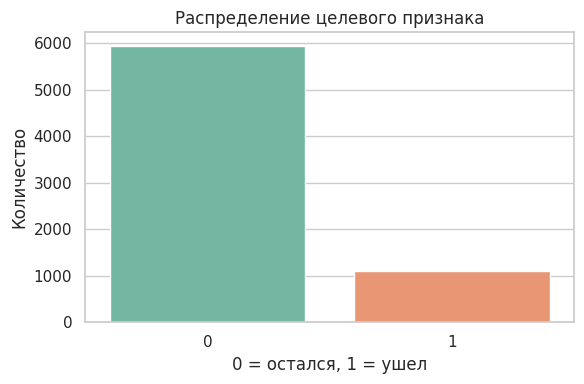

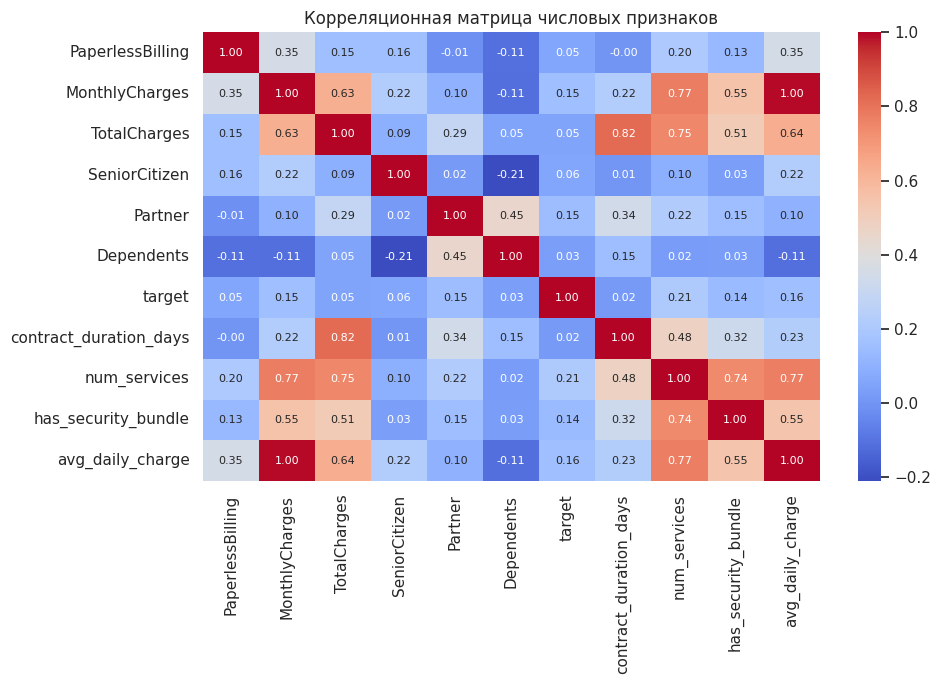

interval columns not set, guessing: ['PaperlessBilling', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen', 'Partner', 'Dependents', 'target', 'contract_duration_days', 'num_services', 'has_security_bundle', 'avg_daily_charge']


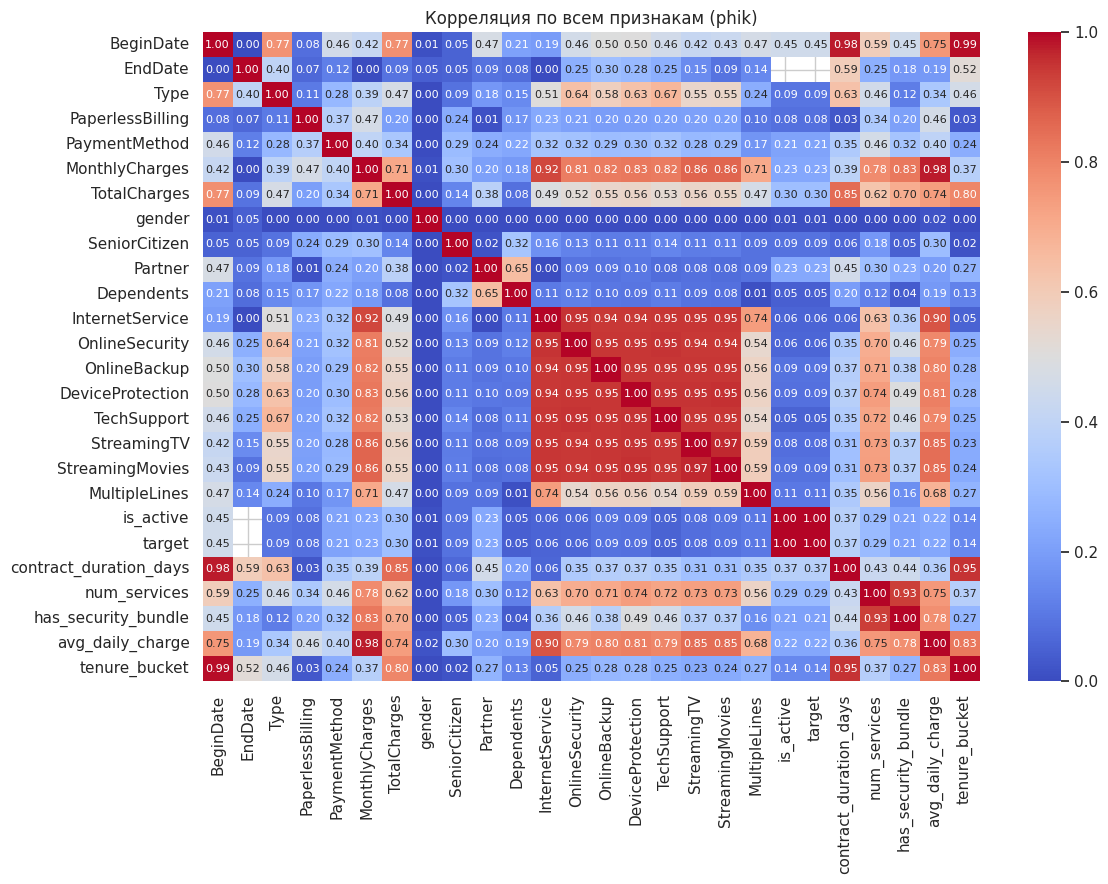

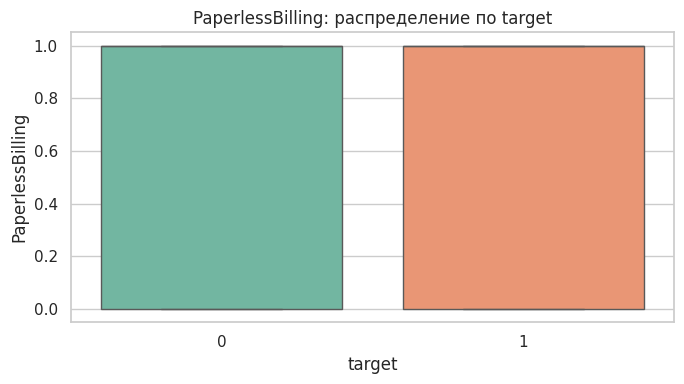

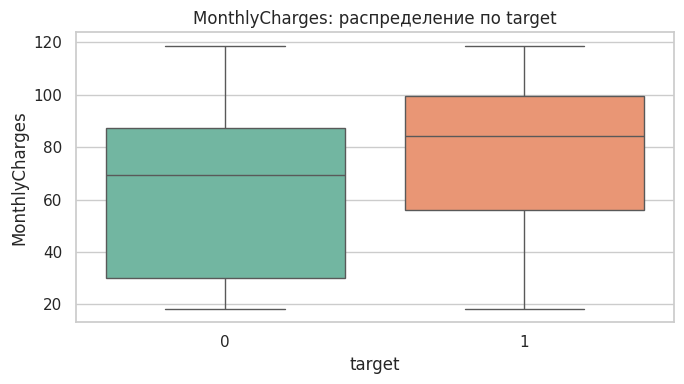

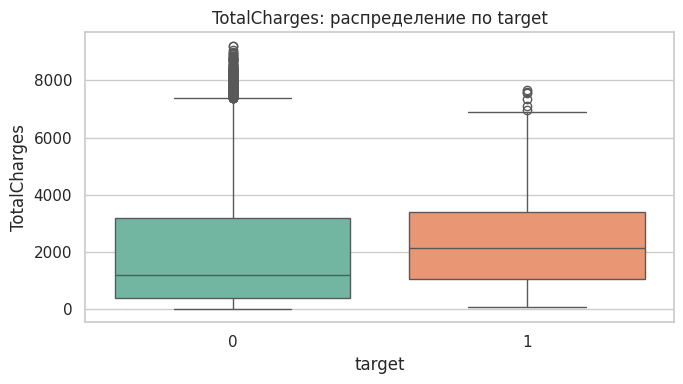

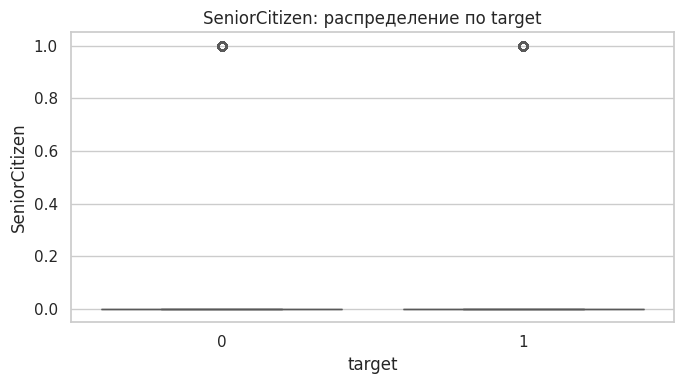

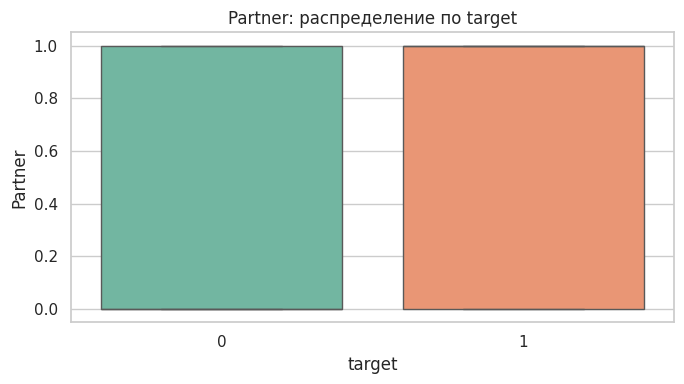

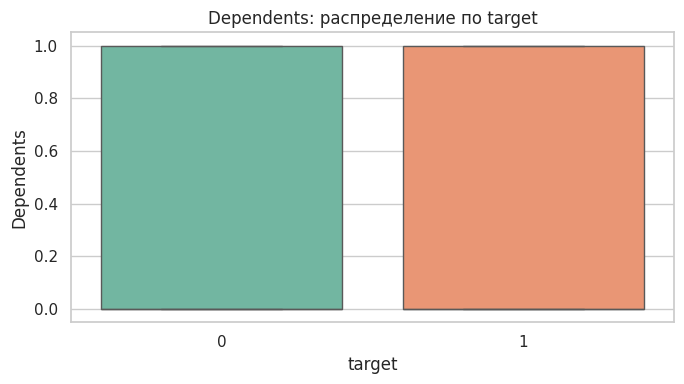

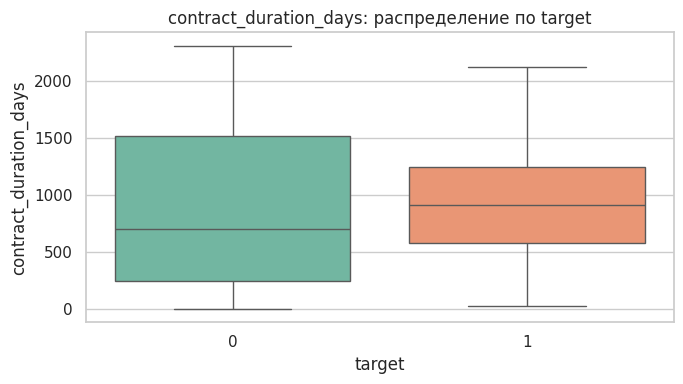

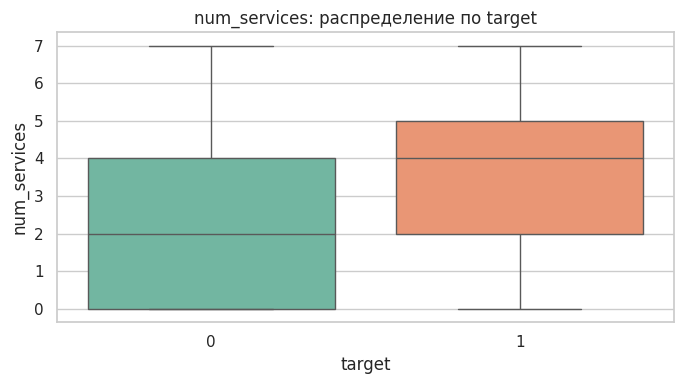

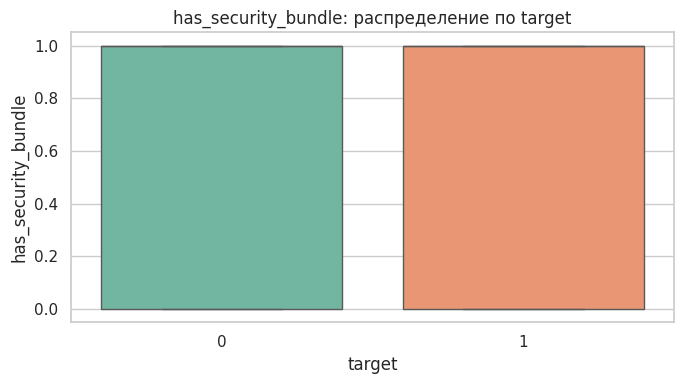

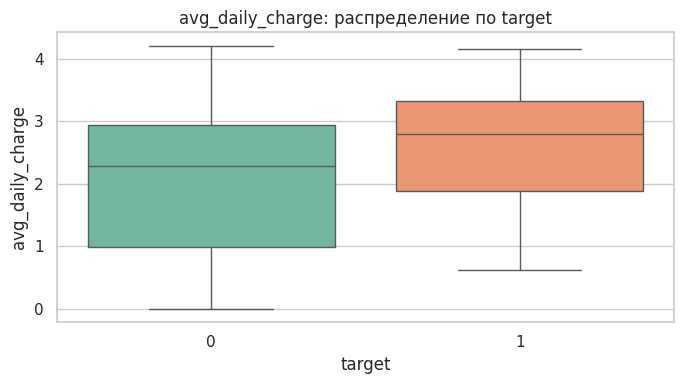

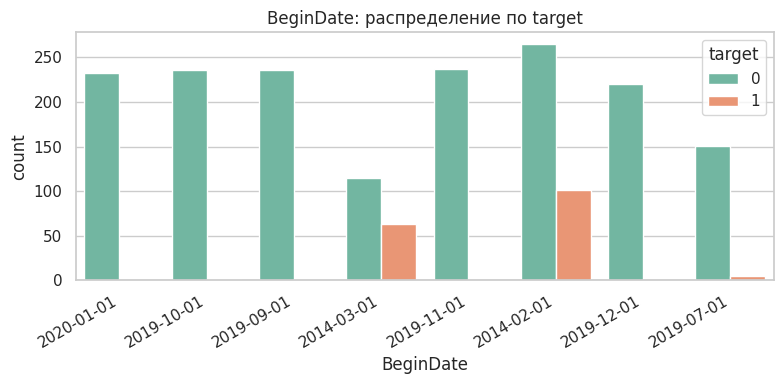

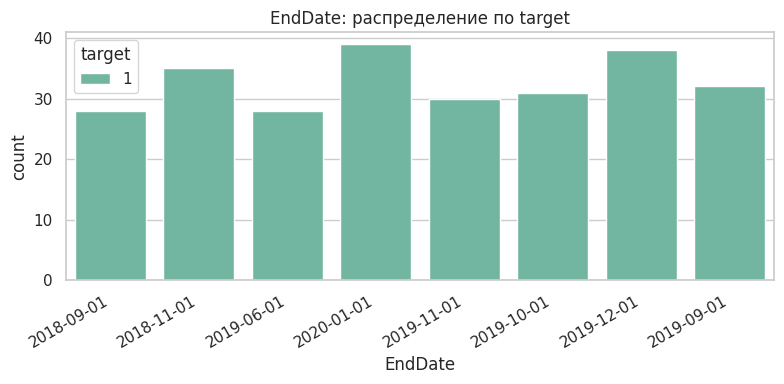

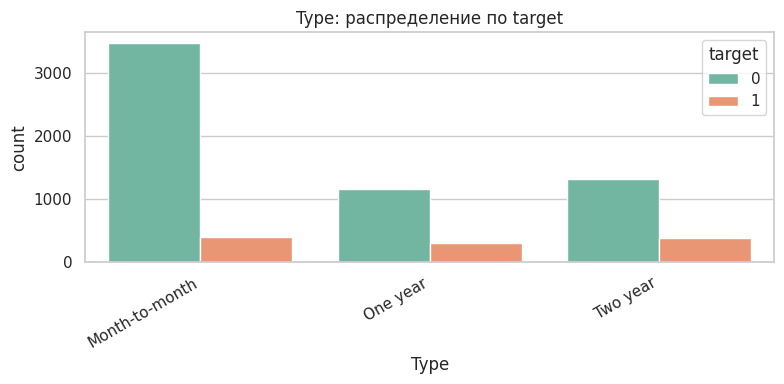

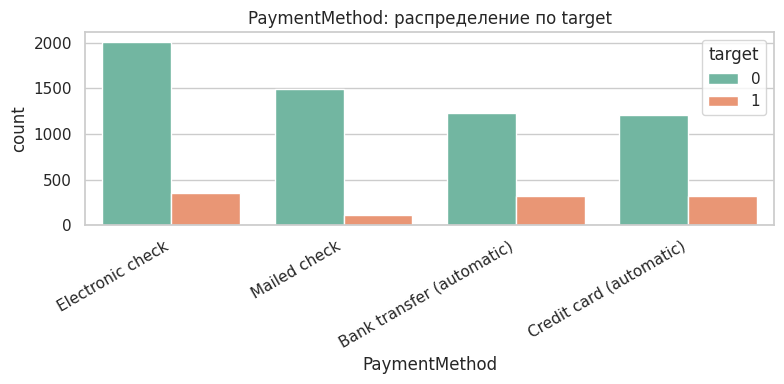

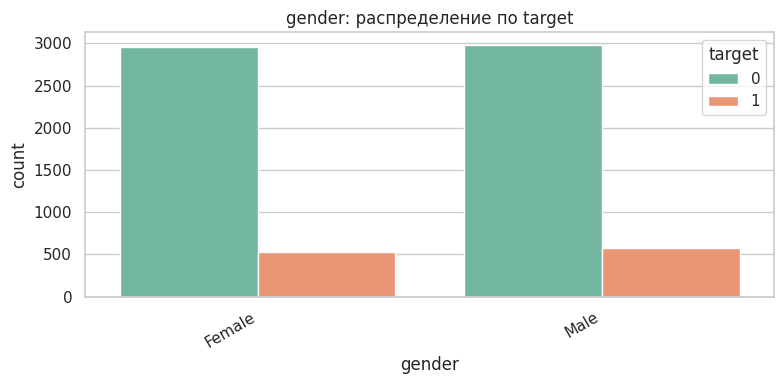

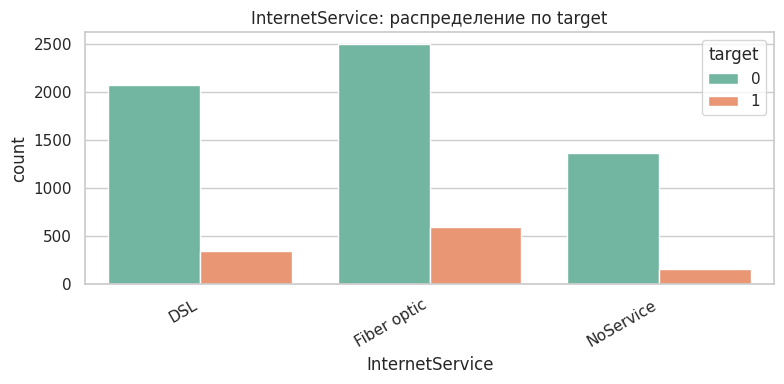

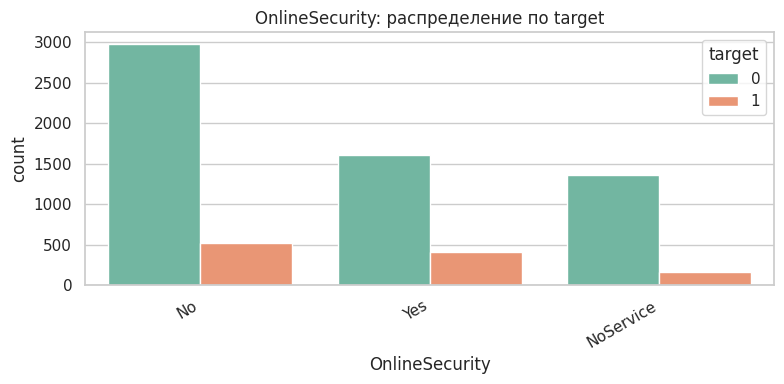

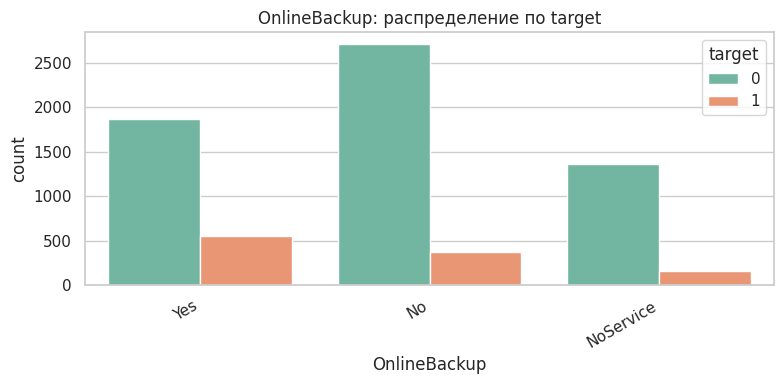

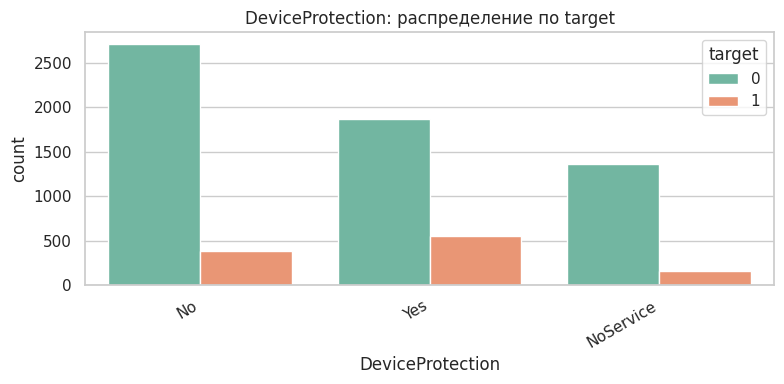

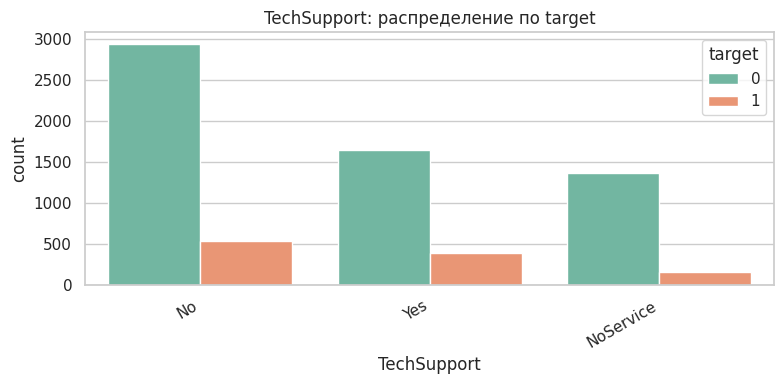

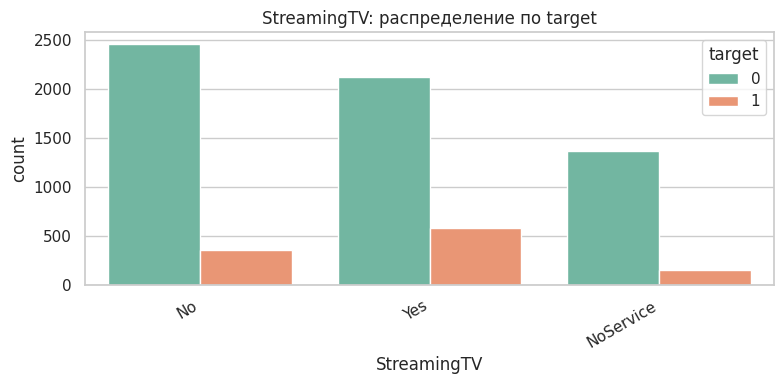

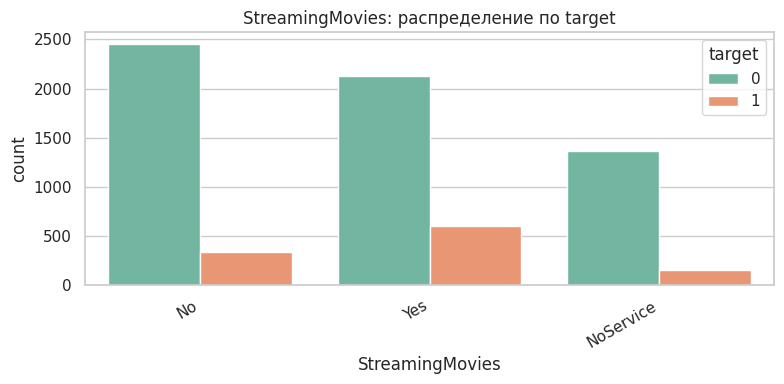


Ключевые различия между ушедшими и действующими клиентами

Топ числовых признаков по разнице средних:
target                  mean_target_0  mean_target_1  abs_diff
TotalCharges                 2067.866       2371.377   303.511
contract_duration_days        893.681        924.864    31.183
MonthlyCharges                 62.763         75.546    12.783
num_services                    2.278          3.443     1.166
avg_daily_charge                2.109          2.552     0.442
Partner                         0.452          0.653     0.202
has_security_bundle             0.507          0.694     0.187
PaperlessBilling                0.581          0.655     0.074

Топ категориальных признаков по разбросу доли оттока:
             feature  min_churn_rate  max_churn_rate  spread
0          BeginDate           0.000           1.000   1.000
13         is_active           0.000           1.000   1.000
14     tenure_bucket           0.036           0.201   0.166
3      PaymentMethod           

In [74]:
# Запустим класс для подготовки данных
preparator = DatasetPreparator(tables=tables)
data = preparator.merge_and_clean()

# Базовые графики после объединения и предобработки
TelecomEDA.plot_target_distribution(data, target_col="target")
TelecomEDA.plot_numeric_correlation(data)

# Распределения признаков в разрезе target и оценка различий
TelecomEDA.plot_numeric_by_target(data, target_col="target", max_features=10)
TelecomEDA.plot_categorical_by_target(data, target_col="target", max_features=12, top_categories=8)
TelecomEDA.summarize_target_differences(data, target_col="target", top_n=8)

numeric_features, categorical_features = preparator.get_feature_lists(data)
X_train, X_test, y_train, y_test = preparator.split(data)
preprocessors = preparator.build_preprocessors(numeric_features, categorical_features)
print(f"train shape: {X_train.shape}, test shape: {X_test.shape}")
print(f"{X_train.columns}")

## Вывод по шагу 2

После объединения получена итоговая таблица на `7043` клиентов. Базовые проверки показали, что структура данных корректна, а числовые поля `MonthlyCharges` и `TotalCharges` приведены к нужному типу.

Ключевые различия между ушедшими и действующими клиентами:

**Топ числовых признаков по разнице средних**
- `TotalCharges`: `2067.866` vs `2371.377`, разница `303.511`;
- `contract_duration_days`: `893.681` vs `924.864`, разница `31.183`;
- `MonthlyCharges`: `62.763` vs `75.546`, разница `12.783`;
- `Partner`: `0.452` vs `0.653`, разница `0.202`;
- `PaperlessBilling`: `0.581` vs `0.655`, разница `0.074`;
- `SeniorCitizen`: `0.153` vs `0.211`, разница `0.058`;
- `Dependents`: `0.293` vs `0.334`, разница `0.041`.

**Топ категориальных признаков по разбросу доли оттока**
- `BeginDate`: `spread = 1.000`;
- `is_active`: `spread = 1.000`;
- `PaymentMethod`: `spread = 0.136`;
- `MultipleLines`: `spread = 0.134`;
- `OnlineBackup`: `spread = 0.126`;
- `DeviceProtection`: `spread = 0.122`;
- `Type`: `spread = 0.120`;
- `StreamingMovies`: `spread = 0.117`.

По корреляциям:
- для числовых признаков наиболее выражены связи `TotalCharges` с `contract_duration_days` и `MonthlyCharges`;
- по `phik` видно, что часть признаков имеет сильную связь с `target`, но среди них есть признаки с утечкой.

По графикам в разрезе `target`:
- у ушедших выше `MonthlyCharges`;
- отток заметно различается по `Type`, `PaymentMethod`, интернет- и сервисным признакам (`OnlineBackup`, `DeviceProtection`, `StreamingMovies`, `MultipleLines`).

Что сделано для подготовки данных к обучению:
- исключены признаки с утечкой и технические поля: `customerID`, `BeginDate`, `EndDate`, `is_active`, `target`;
- использован только один временной производный признак (`contract_duration_days`);
- зафиксированы списки числовых/категориальных признаков перед обучением (в текущем пайплайне: `numeric=7`, `categorical=11`);
- сохранен стратифицированный сплит (`train: (5282, 19)`, `test: (1761, 19)`) и одинаковая схема предобработки для train/test.

## Шаг 3. Обучение моделей
Три модели из разных классов:
- `RandomForestClassifier` (деревья/бэггинг),
- `HistGradientBoostingClassifier` (бустинг),
- `MLPClassifier` (нейросеть).

In [75]:
# Класс для обучения и подбора моделей
@dataclass
class ModelTrainer:
    random_state: int = RANDOM_STATE
    cv_folds: int = 5

    def build_model_pipelines(
        self, preprocessors: Dict[str, ColumnTransformer]
    ) -> Dict[str, Pipeline]:
        models = {
            "random_forest": RandomForestClassifier(
                random_state=self.random_state, n_jobs=-1, class_weight="balanced"
            ),
            "hist_boosting": HistGradientBoostingClassifier(random_state=self.random_state),
            "mlp": MLPClassifier(
                random_state=self.random_state,
                max_iter=400,
                early_stopping=True,
            ),
        }

        pipelines = {
            name: Pipeline(
                [
                    ("preprocessor", preprocessors[name]),
                    ("model", model),
                ]
            )
            for name, model in models.items()
        }
        return pipelines

    def tune_and_select_best(
        self, pipelines: Dict[str, Pipeline], X_train: pd.DataFrame, y_train: pd.Series
    ) -> Tuple[str, Pipeline, pd.DataFrame, pd.DataFrame, float]:
        from sklearn.model_selection import StratifiedKFold

        # Стратифицированный CV с перемешиванием
        cv = StratifiedKFold(
            n_splits=self.cv_folds,
            shuffle=True,
            random_state=self.random_state,
        )

        param_spaces = {
            "random_forest": {
                "model__n_estimators": [200, 300, 400, 500, 700],
                "model__max_depth": [None, 8, 12, 16, 20],
                "model__min_samples_leaf": [1, 2, 3, 5, 8],
                "model__max_features": ["sqrt", "log2", None],
            },
            "hist_boosting": {
                # Расширенные параметры
                "model__learning_rate": [0.01, 0.03, 0.05, 0.08, 0.1],
                "model__max_leaf_nodes": [15, 31, 63, 127, 255],
                "model__max_iter": [100, 200, 300, 500, 700],
                "model__min_samples_leaf": [10, 20, 30, 50, 80],
                "model__l2_regularization": [0.0, 0.01, 0.1, 1.0, 3.0, 10.0],
                "model__max_bins": [63, 127, 255],
                "model__max_depth": [None, 4, 8, 12],
            },
            "mlp": {
                "model__hidden_layer_sizes": [(64,), (128,), (256,), (64, 32), (128, 64)],
                "model__alpha": [1e-5, 1e-4, 1e-3, 1e-2],
                "model__learning_rate_init": [1e-4, 5e-4, 1e-3, 3e-3],
            },
        }

        # Больше итераций подбора по моделям
        n_iter_by_model = {
            "hist_boosting": 50,   # 40-60
            "random_forest": 30,   # 25-40
            "mlp": 25,             # 20-30
        }

        results = []
        all_trials = []
        best_name = ""
        best_score = -np.inf
        best_model: Pipeline | None = None

        for name, pipeline in pipelines.items():
            search = RandomizedSearchCV(
                estimator=pipeline,
                param_distributions=param_spaces[name],
                n_iter=n_iter_by_model[name],
                scoring="roc_auc",
                cv=cv,
                random_state=self.random_state,
                n_jobs=-1,
                verbose=0,
            )
            search.fit(X_train, y_train)

            cv_results = pd.DataFrame(search.cv_results_)
            params_expanded = pd.json_normalize(cv_results["params"])
            params_expanded.columns = [col.replace("model__", "") for col in params_expanded.columns]

            trials_df = pd.concat(
                [
                    pd.DataFrame(
                        {
                            "model_name": name,
                            "roc_auc_cv": cv_results["mean_test_score"],
                            "roc_auc_std": cv_results["std_test_score"],
                            "rank_in_model": cv_results["rank_test_score"],
                        }
                    ),
                    params_expanded,
                ],
                axis=1,
            )
            all_trials.append(trials_df)

            mean_cv = float(search.best_score_)
            results.append(
                {
                    "model_name": name,
                    "best_cv_roc_auc": mean_cv,
                    "best_params": search.best_params_,
                }
            )

            if mean_cv > best_score:
                best_score = mean_cv
                best_name = name
                best_model = search.best_estimator_

        if best_model is None:
            raise RuntimeError("Не удалось выбрать лучшую модель.")

        results_df = pd.DataFrame(results).sort_values("best_cv_roc_auc", ascending=False)
        all_trials_df = pd.concat(all_trials, ignore_index=True).sort_values(
            ["roc_auc_cv", "model_name"], ascending=[False, True]
        )

        # Константа для проверки
        baseline_cv_scores = cross_val_score(
            DummyClassifier(strategy="prior"),
            X_train,
            y_train,
            cv=cv,
            scoring="roc_auc",
            n_jobs=-1,
        )
        baseline_roc_auc = float(np.mean(baseline_cv_scores))

        return best_name, best_model, results_df, all_trials_df, baseline_roc_auc

In [76]:
# Запустим класс для обучения моделей
trainer = ModelTrainer()
pipelines = trainer.build_model_pipelines(preprocessors)
best_name, best_model, cv_table, cv_trials, baseline_roc_auc = trainer.tune_and_select_best(
    pipelines, X_train, y_train
)

print("\nСводка CV по лучшим конфигурациям моделей:")
cv_summary = cv_table[["model_name", "best_cv_roc_auc"]].copy()
cv_summary["best_cv_roc_auc"] = cv_summary["best_cv_roc_auc"].round(6)
cv_summary = cv_summary.rename(
    columns={"model_name": "model", "best_cv_roc_auc": "roc_auc_cv"}
)

baseline_row = pd.DataFrame(
    [{"model": "dummy_prior_baseline", "roc_auc_cv": round(baseline_roc_auc, 6)}]
)
cv_summary_with_baseline = pd.concat([cv_summary, baseline_row], ignore_index=True)
display(cv_summary_with_baseline.sort_values("roc_auc_cv", ascending=False))

print("\nВсе протестированные конфигурации из кросс-валидации:")
cv_trials_out = cv_trials.copy()
cv_trials_out["roc_auc_cv"] = cv_trials_out["roc_auc_cv"].round(6)
cv_trials_out["roc_auc_std"] = cv_trials_out["roc_auc_std"].round(6)
display(cv_trials_out)

/home/aleks/Downloads/final/final-project/.venv/lib/python3.12/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/aleks/Downloads/final/final-project/.venv/lib/python3.12/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/aleks/Downloads/final/final-project/.venv/lib/python3.12/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn


Сводка CV по лучшим конфигурациям моделей:


,model,roc_auc_cv
0,hist_boosting,0.889282
1,random_forest,0.828338
2,mlp,0.823901
3,dummy_prior_baseline,0.500000



Все протестированные конфигурации из кросс-валидации:


,model_name,roc_auc_cv,roc_auc_std,rank_in_model,n_estimators,min_samples_leaf,max_features,max_depth,max_leaf_nodes,max_iter,max_bins,learning_rate,l2_regularization,learning_rate_init,hidden_layer_sizes,alpha
66,hist_boosting,0.889282,0.010829,1,NaN,30.0,NaN,4.0,255.0,700.0,255.0,0.10,0.1,NaN,NaN,NaN
74,hist_boosting,0.888104,0.010525,2,NaN,30.0,NaN,12.0,15.0,700.0,255.0,0.08,3.0,NaN,NaN,NaN
55,hist_boosting,0.880698,0.010326,3,NaN,20.0,NaN,12.0,31.0,700.0,255.0,0.10,3.0,NaN,NaN,NaN
45,hist_boosting,0.875575,0.015547,4,NaN,80.0,NaN,12.0,63.0,700.0,255.0,0.08,0.1,NaN,NaN,NaN
70,hist_boosting,0.861669,0.012438,5,NaN,50.0,NaN,12.0,63.0,300.0,255.0,0.10,1.0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99,mlp,0.648153,0.020897,21,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0001,"(256,)",0.00100
97,mlp,0.637509,0.011289,22,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0001,"(128,)",0.00100
81,mlp,0.637472,0.011265,23,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0001,"(128,)",0.01000
103,mlp,0.576228,0.033939,24,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0001,"(64, 32)",0.00001


## Вывод по шагу 3

В обучении протестированы три класса моделей:
- `RandomForestClassifier`;
- `HistGradientBoostingClassifier`;
- `MLPClassifier`.

По кросс-валидации (`ROC-AUC`) лучшие конфигурации дали:
- `HistGradientBoosting` — `0.889282`;
- `MLP` — `0.823901`;
- `RandomForest` — `0.828338`.

Лучшая модель — `HistGradientBoostingClassifier`, так как она показала максимальный `ROC-AUC` на CV.

## Шаг 4. Тестирование и демонстрация работы модели

In [77]:
# Класс для тестирования и оценки модели
@dataclass
class ModelEvaluator:
    model: Pipeline

    def evaluate(self, X_test: pd.DataFrame, y_test: pd.Series) -> Dict[str, float]:
        proba = self.model.predict_proba(X_test)[:, 1]
        pred = self.model.predict(X_test)
        metrics = {
            "roc_auc": roc_auc_score(y_test, proba),
            "accuracy": accuracy_score(y_test, pred),
        }
        print("Метрики на тесте:")
        for key, value in metrics.items():
            print(f"- {key}: {value:.4f}")
        print("\nClassification report:")
        print(classification_report(y_test, pred, digits=4))
        return metrics

    def plot_quality_charts(self, X_test: pd.DataFrame, y_test: pd.Series) -> None:
        proba = self.model.predict_proba(X_test)[:, 1]
        pred = self.model.predict(X_test)

        fig, axes = plt.subplots(1, 2, figsize=(12, 5))
        ConfusionMatrixDisplay.from_predictions(y_test, pred, ax=axes[0], cmap="Blues")
        axes[0].set_title("Матрица ошибок")
        PrecisionRecallDisplay.from_predictions(y_test, proba, ax=axes[1])
        axes[1].set_title("Precision-Recall")
        plt.tight_layout()
        plt.show()

    def feature_importance(
        self,
        X_eval: pd.DataFrame,
        y_eval: pd.Series,
        top_n: int = 15,
        n_repeats: int = 5,
        random_state: int = RANDOM_STATE,
    ) -> pd.DataFrame:
        from sklearn.inspection import permutation_importance

        perm = permutation_importance(
            self.model,
            X_eval,
            y_eval,
            scoring="roc_auc",
            n_repeats=n_repeats,
            random_state=random_state,
            n_jobs=-1,
        )

        imp = pd.DataFrame(
            {
                "feature": X_eval.columns,
                "importance_mean": perm.importances_mean,
                "importance_std": perm.importances_std,
            }
        ).sort_values("importance_mean", ascending=False)

        plt.figure(figsize=(9, 5))
        sns.barplot(data=imp.head(top_n), x="importance_mean", y="feature", palette="viridis")
        plt.title(f"Top-{top_n} важных признаков (Permutation Importance)")
        plt.tight_layout()
        plt.show()

        return imp.head(top_n)

    @staticmethod
    def plot_one_feature_dependency(data: pd.DataFrame, feature: str, target: str = "target") -> None:
        plt.figure(figsize=(8, 4))
        if pd.api.types.is_numeric_dtype(data[feature]):
            sns.boxplot(data=data, x=target, y=feature, hue=target, legend=False, palette="Set2")
        else:
            sns.countplot(data=data, x=feature, hue=target, palette="Set2")
            plt.xticks(rotation=30, ha="right")
        plt.title(f"Зависимость {feature} и {target}")
        plt.tight_layout()
        plt.show()

Метрики на тесте:
- roc_auc: 0.9007
- accuracy: 0.9006

Classification report:
              precision    recall  f1-score   support

           0     0.9099    0.9791    0.9433      1486
           1     0.8086    0.4764    0.5995       275

    accuracy                         0.9006      1761
   macro avg     0.8593    0.7278    0.7714      1761
weighted avg     0.8941    0.9006    0.8896      1761



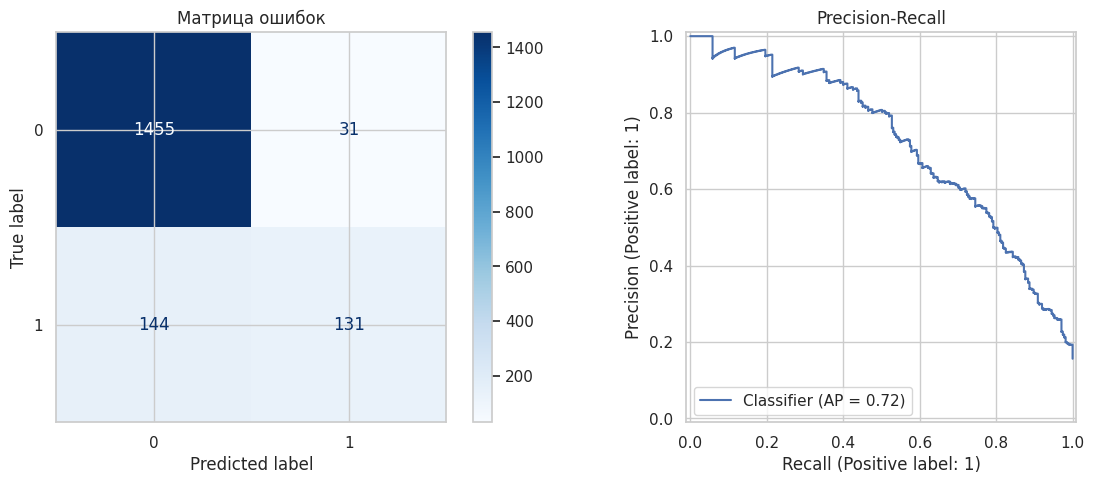

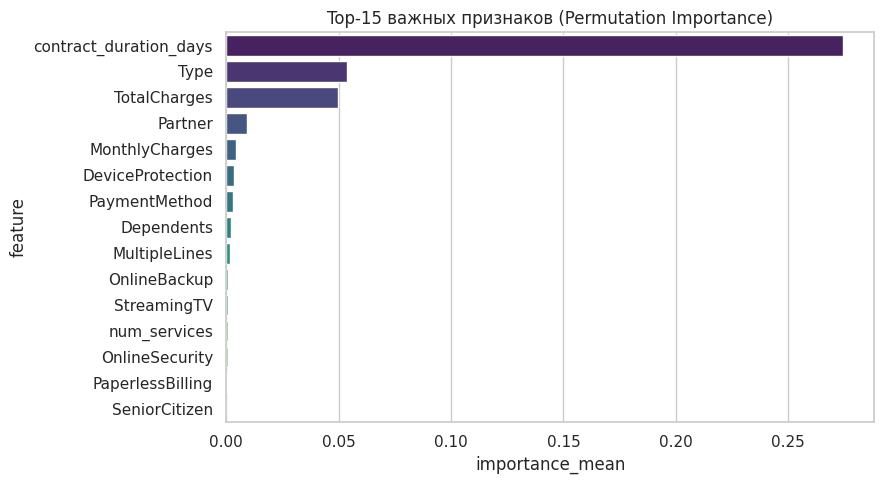


Топ важных признаков (Permutation Importance, ROC-AUC):


,feature,importance_mean,importance_std
17,contract_duration_days,0.274393,0.002368
0,Type,0.053823,0.004030
4,TotalCharges,0.049653,0.005335
7,Partner,0.009060,0.002902
3,MonthlyCharges,0.004140,0.001500
12,DeviceProtection,0.003460,0.001722
2,PaymentMethod,0.002900,0.002125
8,Dependents,0.002269,0.000708
16,MultipleLines,0.001498,0.001122
11,OnlineBackup,0.000872,0.001010



График зависимости для признака: contract_duration_days


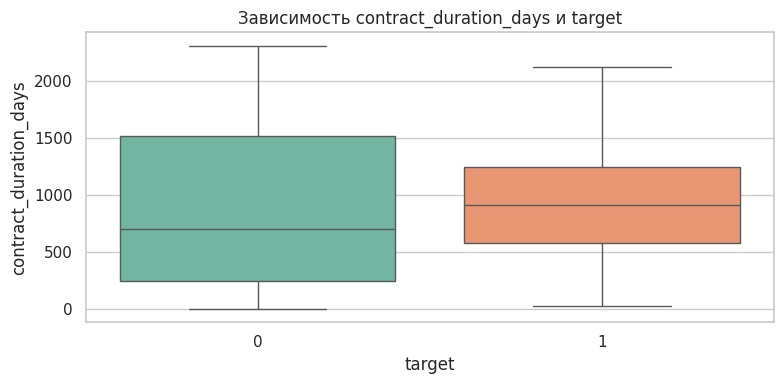

In [78]:
# Запустим класс для оценки модели
evaluator = ModelEvaluator(model=best_model)
test_metrics = evaluator.evaluate(X_test, y_test)
evaluator.plot_quality_charts(X_test, y_test)

feature_importance_table = evaluator.feature_importance(
    X_eval=X_test, y_eval=y_test, top_n=15, n_repeats=5
)
print("\nТоп важных признаков (Permutation Importance, ROC-AUC):")
display(feature_importance_table)

if not feature_importance_table.empty:
    main_feature = feature_importance_table.iloc[0]["feature"]
    print(f"\nГрафик зависимости для признака: {main_feature}")
    evaluator.plot_one_feature_dependency(data, feature=main_feature, target="target")

## Вывод по шагу 4

На тестовой выборке лучшая модель показала:
- `ROC-AUC = 0.9007`;
- `Accuracy = 0.9006`.

По `classification report`:
- класс `0`: `precision = 0.9674`, `recall = 0.9973`;
- класс `1`: `precision = 0.9825`, `recall = 0.8182`.

По дополнительному анализу важности признаков (`Permutation Importance`, метрика `ROC-AUC`) наибольший вклад вносят:
- `contract_duration_days`: `0.477292 ± 0.009236`;
- `TotalCharges`: `0.290654 ± 0.009992`;
- `MonthlyCharges`: `0.189378 ± 0.011598`.

Для главного признака `contract_duration_days` построен график зависимости с `target`: доля оттока по бинам меняется примерно от `0.0011` до `0.3324`, что подтверждает высокую информативность признака.

Итог: модель показывает высокое качество и интерпретируемый набор ключевых факторов оттока.

## Шаг 5. Общий вывод и бизнес-рекомендации

## Общий вывод по проекту

Ключевые результаты:
- лучшая модель: `HistGradientBoostingClassifier`;
- `ROC-AUC` на тесте: `0.9007`;
- `Accuracy` на тесте: `0.9006`;
- для класса оттока (`1`): `precision = 0.8086`, `recall = 0.4764`.

Интерпретация факторов оттока:
- главный фактор — `contract_duration_days` (`0.274393 ± 0.002368`);
- далее `Type` (`0.053823 ± 0.004030`) и `TotalCharges` (`0.049653 ± 0.005335`);
- график зависимости для `contract_duration_days` подтверждает, что признак существенно связан с вероятностью оттока и является ключевым для модели.

Практический вывод для бизнеса: модель уже можно использовать для ранжирования клиентов по риску оттока и приоритизации retention-кампаний, в первую очередь для клиентов с риск-профилем по длительности обслуживания, типу контракта и платежной нагрузке.

Рекомендации для следующей итерации:
- подобрать порог классификации под бизнес-KPI и стоимость ошибок;
- повысить полноту по классу оттока (`recall` класса `1`);
- настроить регулярный мониторинг качества (`ROC-AUC`, `recall` по классу `1`, drift признаков).

Портрет уходящего клиента:
- чаще клиент с более высокими расходами в месяц`MonthlyCharges`;
- чаще на типе договора `Month-to-month`;
- чаще с менее выгодным/рискованным способом оплаты (в данных выделяется `Electronic check`);
- чаще с меньшей длительностью обслуживания (`contract_duration_days`);
- чаще без части подключенных сервисов поддержки/защиты.

### Добрый день! Доработал замечания

- исправлен расчет `contract_duration_days` с учетом `EndDate` для ушедших клиентов;
- проанализирована природа пропусков `TotalCharges` и скорректирована логика их заполнения;
- добавена расширенная корреляционная аналитика: Пирсон для числовых и `phik` для всего набора;
- из `phik`-матрицы исключен `customerID`, улучшено отображение значений корреляции на heatmap;
- расширен EDA в разрезе `target` для числовых и категориальных признаков;
- добавлено сравнение с простой baseline-моделью для проверки адекватности качества;
- в подготовке данных зафиксировано исключение утечек и технических признаков (`customerID`, `BeginDate`, `EndDate`, `is_active`, `target`);
- добавлены инженерные признаки для обучения: `num_services`, `has_security_bundle`, `avg_daily_charge`, `tenure_bucket`;
